# 10. Метод переноса обучения (Transfer Learning)

**Перенос обучения** - это техника машинного обучения, при которой модель, предварительно обученная на большой dataset (например, ImageNet), используется в качестве отправной точки для решения новой, но схожей задачи.

Основная идея:

- Использовать знания, полученные на большой dataset
- Адаптировать модель для новой задачи с меньшим объемом данных
- Сократить время обучения и улучшить качество


Преимущества переноса обучения:

1.  Экономия времени
2.  Требуется меньше данных - особенно важно для медицинских изображений и т.д.
3.  Лучшая производительность - предобученные модели уже научились полезным признакам
4.  Упрощение процесса - не нужно проектировать архитектуру с нуля


Типы переноса обучения в PyTorch
1. Feature Extraction (Извлечение признаков):

   ### Заморозка всех слоев кроме последнего

```
   for param in model.parameters():
       param.requires_grad = False
   Замена классификатора
   model.fc = nn.Linear(model.fc.in_features, num_classes)
```


2. Fine-Tuning (Тонкая настройка):
   ### Разморозка последних слоев
```
   for param in model.parameters():
       param.requires_grad = False
```
   ### Разморозка последних N слоев
```
   for param in model.layer4.parameters():
       param.requires_grad = True
```
## Порядок работы:

## Шаг 1: Выбор предобученной модели:



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
from typing import Tuple, Dict, List

In [ ]:
import torchvision.models as models

#Доступные модели (https://docs.pytorch.org/vision/main/models.html#classification)

resnet18 = models.resnet18(pretrained=True)
resnet34 = models.resnet34(pretrained=True)
resnet50 = models.resnet50(pretrained=True)
vgg16 = models.vgg16(pretrained=True)
alexnet = models.alexnet(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 231MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 192MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


...

100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 94.1MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 132MB/s]


1. Нормализация данных
2. Размер изображений
3. Выбор слоя для замены

## Шаг 2: Адаптация модели под задачу
   

In [2]:
def seeder():
  torch.manual_seed(42)
  torch.cuda.manual_seed(42)

In [3]:
seeder()

In [ ]:
class TransferLearningModel(nn.Module):
    def __init__(self, base_model='resnet18', num_classes=10, freeze_backbone=True):
        super().__init__()

        # Загрузка предобученной модели
        if base_model == 'resnet18':
            self.backbone = models.resnet18(pretrained=True)
        elif base_model == 'resnet34':
            self.backbone = models.resnet34(pretrained=True)

        # Заморозка весов
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Замена последнего слоя
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


## Шаг 3: Подготовка данных

In [ ]:
def get_data_transforms():
    # Для тренировочных данных - аугментация
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Для тестовых данных - только нормализация
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    return train_transform, test_transform


## Стратегии обучения

## Стратегия 1: Только классификатор


In [ ]:
def train_only_classifier(model, train_loader, epochs=10):
    # Заморозка backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Обучение только последнего слоя
    optimizer = optim.Adam(model.backbone.fc.parameters(), lr=0.001)

    for epoch in range(epochs):
      skip
# Процесс обучения...


## Стратегия 2: Поэтапная разморозка


In [ ]:
def progressive_unfreezing(model, train_loader, epochs=20):
    # Фаза 1: Только классификатор (эпохи 1-5)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.backbone.fc.parameters():
        param.requires_grad = True

    # Фаза 2: Последние слои (эпохи 6-15)
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

    # Фаза 3: Все слои (эпохи 16-20)
    for param in model.parameters():
        param.requires_grad = True

## Стратегия 3: Разные learning rates

In [ ]:
def differential_learning_rates(model):
    # Группировка параметров с разными LR
    optimizer = optim.SGD([
        {'params': model.backbone.conv1.parameters(), 'lr': 0.0001},
        {'params': model.backbone.layer1.parameters(), 'lr': 0.001},
        {'params': model.backbone.layer2.parameters(), 'lr': 0.01},
        {'params': model.backbone.fc.parameters(), 'lr': 0.1}
    ], momentum=0.9)


## Перенос обучения:
Хорошо работает когда:
- Мало тренировочных данных (< 10K примеров)
- Новая задача похожа на исходную
- Вычислительные ресурсы ограничены

Менее эффективно когда:
- Новые данные сильно отличаются от исходных
- Очень много данных для новой задачи
- Требуется специализированная архитектура

In [ ]:
# !pip install --upgrade torch torchvision torchaudio

In [ ]:
available_models = {
    "resnet18": resnet18,
    "resnet34": resnet34,
    "resnet50": resnet50,
    "vgg16": vgg16,
    "alexnet": alexnet
}

In [ ]:
backbone = resnet18
# Определение модели с переносом обучения
class TransferLearningModel(nn.Module):
    def __init__(self, base_model = backbone, num_classes: int = 10, freeze_backbone: bool = True):
        """
        Инициализация модели для переноса обучения

        Args:
            base_model: базовая модель ('resnet18', 'resnet34', 'resnet50')
            num_classes: количество классов для классификации
            freeze_backbone: заморозить ли веса базовой модели
        """
        super(TransferLearningModel, self).__init__()

        # Загрузка предобученной модели
        self.backbone = backbone

        # Заморозка весов базовой модели (опционально)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Замена последнего слоя для нашего количества классов
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [ ]:
# Функции для работы с данными
def get_data_loaders(batch_size: int = 128) -> Tuple[DataLoader, DataLoader]:
    """
    Создание DataLoader для тренировочных и тестовых данных

    Args:
        batch_size: размер батча

    Returns:
        Кортеж (train_loader, test_loader)
    """
    # Аугментации для тренировочных данных
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Трансформации для тестовых данных
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    # Загрузка datasets
    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    # Создание DataLoader
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [4]:
# Функции для обучения
def train_epoch(model: nn.Module,
                train_loader: DataLoader,
                criterion: nn.Module,
                optimizer: optim.Optimizer,
                device: torch.device) -> float:
    """
    Обучение модели на одной эпохе

    Args:
        model: модель для обучения
        train_loader: DataLoader тренировочных данных
        criterion: функция потерь
        optimizer: оптимизатор
        device: устройство (CPU/GPU)

    Returns:
        Среднее значение потерь за эпоху
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = running_loss / len(train_loader)

    print(f'Train Loss: {avg_loss:.4f} | Train Acc: {accuracy:.2f}%')
    return avg_loss

def evaluate(model: nn.Module,
             test_loader: DataLoader,
             criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    """
    Оценка модели на тестовых данных

    Args:
        model: модель для оценки
        test_loader: DataLoader тестовых данных
        criterion: функция потерь
        device: устройство (CPU/GPU)

    Returns:
        Кортеж (потери, точность)
    """
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    accuracy = 100. * correct / total
    avg_loss = test_loss / len(test_loader)

    print(f'Test Loss: {avg_loss:.4f} | Test Acc: {accuracy:.2f}%')
    return avg_loss, accuracy

def train_model(model: nn.Module,
                train_loader: DataLoader,
                test_loader: DataLoader,
                epochs: int = 10,
                learning_rate: float = 0.001,
                method_name: str = "") -> Dict:
    """
    Полный цикл обучения модели

    Args:
        model: модель для обучения
        train_loader: DataLoader тренировочных данных
        test_loader: DataLoader тестовых данных
        epochs: количество эпох
        learning_rate: скорость обучения

    Returns:
        Словарь с историей обучения
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Training with {method_name}")

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    history = {
        'train_loss': [],
        'test_loss': [],
        'test_accuracy': [],
        'training_time': 0
    }

    start_time = time.time()

    for epoch in range(epochs):
        print(f'\nEpoch: {epoch + 1}/{epochs}')
        print('-' * 50)

        # Обучение
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

        # Оценка
        test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

        # Обновление scheduler
        scheduler.step()

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_accuracy'].append(test_accuracy)

    training_time = time.time() - start_time
    history['training_time'] = training_time
    print(f'\nTraining completed in {training_time:.2f} seconds')

    return history

In [ ]:
# Функция для создания и обучения модели
def run_transfer_learning_experiment(base_model: str = 'resnet18',
                                   epochs: int = 15,
                                   batch_size: int = 128,
                                   freeze_backbone: bool = True) -> Dict:
    """
    Запуск эксперимента с переносом обучения

    Args:
        base_model: базовая модель
        epochs: количество эпох
        batch_size: размер батча
        freeze_backbone: заморозить ли backbone

    Returns:
        История обучения
    """
    print(f"Starting transfer learning experiment with {base_model}")
    print(f"Freeze backbone: {freeze_backbone}")

    # Создание модели
    model = TransferLearningModel(
        base_model=base_model,
        num_classes=10,
        freeze_backbone=freeze_backbone
    )

    # Получение данных
    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    # Обучение
    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=0.001
    )

    return history

## Задание 1:

- 1.1. Используйте предобученную ResNet-18 для классификации CIFAR-10
- 1.2. Реализуйте два подхода: feature extraction (замороженный backbone) и fine-tuning
- 1.3. Сравните точность и время обучения обоих подходов
- 1.4. Проанализируйте, какой метод работает лучше и почему

In [ ]:
try:
    # Один эксперимент
    print("Running single experiment with ResNet-18")
    history = run_transfer_learning_experiment(
        base_model=torchvision.models.resnet18(pretrained=True),
        epochs=15,
        batch_size=128,
        freeze_backbone=True
    )

    # Эксперимент с размороженным backbone
    print("\nRunning experiment with unfrozen backbone...")
    history_unfrozen = run_transfer_learning_experiment(
        base_model=torchvision.models.resnet18(pretrained=True),
        epochs=15,
        batch_size=128,
        freeze_backbone=False
    )
except Exception as e:
    print(str(e))

Running single experiment with ResNet-18
Starting transfer learning experiment with ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, mome

100%|██████████| 170M/170M [00:19<00:00, 8.61MB/s]


Using device: cuda

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.8547 | Train Acc: 34.63%
Test Loss: 1.7505 | Test Acc: 39.59%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.7189 | Train Acc: 39.68%
Test Loss: 1.7502 | Test Acc: 39.81%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.6987 | Train Acc: 40.75%
Test Loss: 1.6987 | Test Acc: 41.26%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.6780 | Train Acc: 41.01%
Test Loss: 1.7123 | Test Acc: 40.38%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.6740 | Train Acc: 41.31%
Test Loss: 1.7099 | Test Acc: 41.21%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.6838 | Train Acc: 40.99%
Test Loss: 1.7097 | Test Acc: 41.49%

Epoch: 7/15
--------------------------------------------------
Train Loss: 1.6794 | Train Acc: 41.10%
Test Loss: 1.6987 | Test Acc: 41.23%



In [ ]:
def run_feature_extraction(base_model: str = "resnet18",
                          epochs: int = 10,
                          batch_size: int = 128,
                          learning_rate: float = 0.001) -> Dict:

    model = TransferLearningModel(num_classes=10, base_model=base_model, freeze_backbone=True)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        method_name="Feature Extraction"
    )

    return history

In [ ]:
def run_fine_tuning(base_model: str = "resnet18",
                   epochs: int = 10,
                   batch_size: int = 128,
                   learning_rate: float = 0.0001) -> Dict:

    model = TransferLearningModel(num_classes=10, base_model=base_model, freeze_backbone=False)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

    train_loader, test_loader = get_data_loaders(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        method_name="Fine-Tuning"
    )

    return history

In [ ]:
# 1. Feature Extraction

history_fe = run_feature_extraction(
    base_model=torchvision.models.resnet18(pretrained=True),
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Trainable parameters: 5,130 / 11,181,642
Using device: cuda
Training with Feature Extraction

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.8522 | Train Acc: 34.97%
Test Loss: 1.7631 | Test Acc: 39.22%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.7224 | Train Acc: 39.64%
Test Loss: 1.7278 | Test Acc: 39.95%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.6953 | Train Acc: 40.42%
Test Loss: 1.7157 | Test Acc: 40.49%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.6831 | Train Acc: 41.22%
Test Loss: 1.7172 | Test Acc: 40.97%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.6782 | Train Acc: 41.27%
Test Loss: 1.7313 | Test Acc: 40.63%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.6781 | Train Acc: 41.17%
Test Loss: 1.7154 | Test Acc: 40.70%

Epoch: 7/15
--------------------------------------------------
Tra

In [ ]:
history_ft = run_fine_tuning(
    base_model=torchvision.models.resnet18(pretrained=True),
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)

Trainable parameters: 5,130 / 11,181,642
Using device: cuda
Training with Fine-Tuning

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.8426 | Train Acc: 35.14%
Test Loss: 1.7556 | Test Acc: 39.22%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.7171 | Train Acc: 39.90%
Test Loss: 1.7480 | Test Acc: 39.69%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.6967 | Train Acc: 40.65%
Test Loss: 1.7067 | Test Acc: 40.28%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.6830 | Train Acc: 40.97%
Test Loss: 1.7197 | Test Acc: 40.91%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.6772 | Train Acc: 41.29%
Test Loss: 1.7128 | Test Acc: 40.86%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.6704 | Train Acc: 41.62%
Test Loss: 1.7291 | Test Acc: 40.60%

Epoch: 7/15
--------------------------------------------------
Train Loss

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
def plot_comparison(results):
    for name, data in results.items():
        print(f"{name}: {data['training_time']:.2f} сек")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))

    ax = axes[0]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_loss']) + 1)
        ax.plot(epochs, data['test_loss'], label=name, color=color, linewidth=2.5, marker='o', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_title('Test Loss по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_accuracy']) + 1)
        ax.plot(epochs, data['test_accuracy'], label=name, color=color, linewidth=2.5, marker='s', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Accuracy', fontsize=16)
    ax.set_title('Test Accuracy по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
results = {
    'Feature Extraction': history_fe,
    'Fine-Tuning': history_ft
}

Feature Extraction: 313.22 сек
Fine-Tuning: 320.40 сек


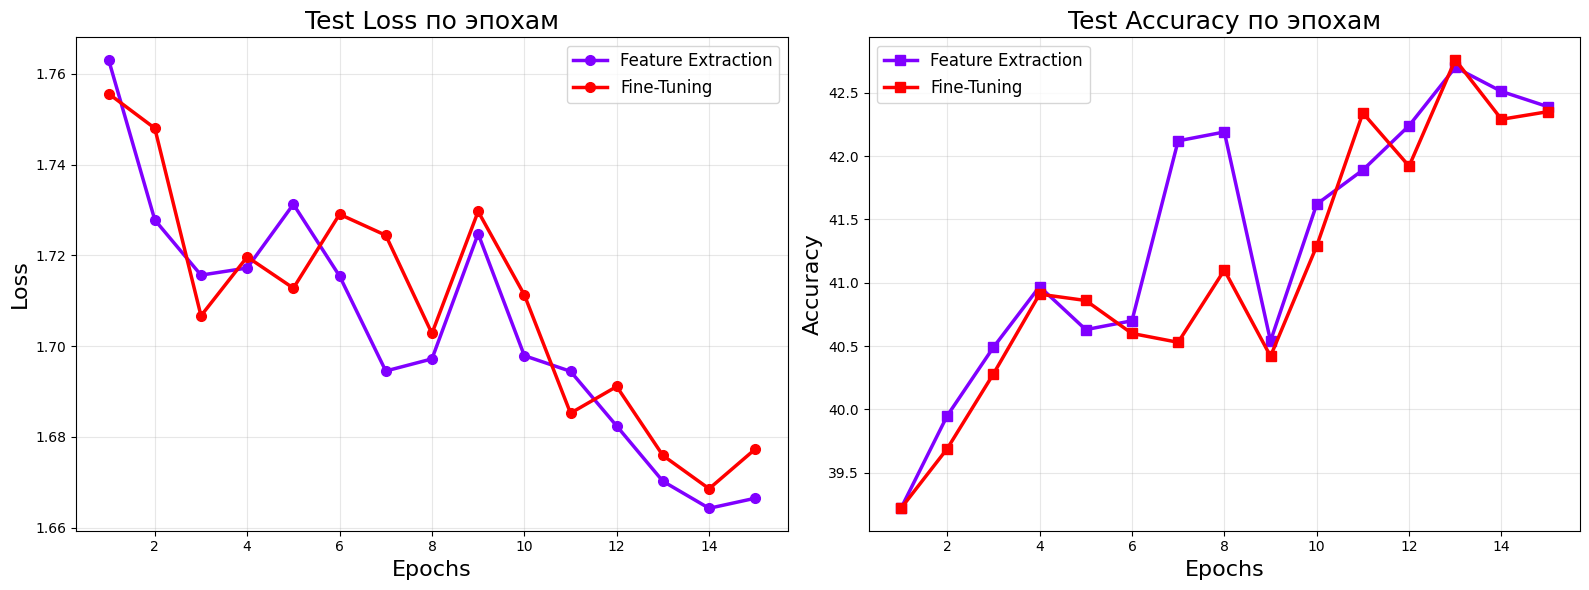

In [ ]:
plot_comparison(results)

### Выводы

Получились примерно одинаковые результаты. Т.к. CIFAR имеет немного данных, а также CIFAR и ImageNet, на котором обучался ResNet, содержат похожие классы, то предобученные признаки уже релевантны. Хотя канонически лучше подойдёт Feature Extracting, т.к. задача похожа, данных не много.

## Задание 2: Сравнение архитектур моделей

- 2.1. Выберите 3 различные архитектуры (например, ResNet, VGG, AlexNet)
- 2.2. Примените перенос обучения на CIFAR-10 для каждой архитектуры
- 2.3. Сравните производительность, количество параметров и время сходимости (Таблица сравнения метрик)
- 2.4. Определите наиболее эффективную архитектуру для данной задачи

In [ ]:
class TransferLearningModel(nn.Module):
    def __init__(self, base_model: str = "resnet18", num_classes: int = 10, freeze_backbone: bool = True):
        super(TransferLearningModel, self).__init__()

        if base_model == "resnet18":
            self.backbone = models.resnet18(pretrained=True)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(num_features, num_classes)

        elif base_model == "vgg16":
            self.backbone = models.vgg16(pretrained=True)
            num_features = self.backbone.classifier[6].in_features
            self.backbone.classifier[6] = nn.Linear(num_features, num_classes)

        elif base_model == "alexnet":
            self.backbone = models.alexnet(pretrained=True)
            num_features = self.backbone.classifier[6].in_features
            self.backbone.classifier[6] = nn.Linear(num_features, num_classes)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

            if base_model == "resnet18":
                for param in self.backbone.fc.parameters():
                    param.requires_grad = True
            else:
                for param in self.backbone.classifier[6].parameters():
                    param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

In [11]:
def get_data_loaders_new(batch_size: int = 128) -> Tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(64, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    test_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [ ]:
def run_architecture_experiment(base_model: str = "resnet18",
                                epochs: int = 15,
                                batch_size: int = 128,
                                learning_rate: float = 0.001) -> Dict:

    model = TransferLearningModel(num_classes=10, base_model=base_model, freeze_backbone=True)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Всего параметров: {total_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,}")

    train_loader, test_loader = get_data_loaders_new(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        method_name=f"{base_model}"
    )

    history['total_params'] = total_params
    history['trainable_params'] = trainable_params
    history['model_name'] = base_model

    return history

In [ ]:
results = {}

In [ ]:
history = run_architecture_experiment(
    base_model='resnet18',
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)
results['resnet18'] = history

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Всего параметров: 11,181,642
Обучаемых параметров: 5,130
Using device: cuda
Training with resnet18

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.4724 | Train Acc: 49.35%
Test Loss: 1.3238 | Test Acc: 55.32%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.2879 | Train Acc: 55.76%
Test Loss: 1.3017 | Test Acc: 56.13%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.2555 | Train Acc: 57.29%
Test Loss: 1.2840 | Test Acc: 57.16%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.2501 | Train Acc: 56.91%
Test Loss: 1.2697 | Test Acc: 56.91%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.2429 | Train Acc: 57.24%
Test Loss: 1.2596 | Test Acc: 57.71%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.2407 | Train Acc: 57.45%
Test Loss: 1.2537 | Test Acc: 57.36%

Epoch: 7/15
------------------------------------------------

In [ ]:
history = run_architecture_experiment(
    base_model='vgg16',
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)
results['vgg16'] = history

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Всего параметров: 134,301,514
Обучаемых параметров: 40,970
Using device: cuda
Training with vgg16

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.1986 | Train Acc: 58.88%
Test Loss: 0.9176 | Test Acc: 69.13%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.1487 | Train Acc: 61.10%
Test Loss: 0.8937 | Test Acc: 71.01%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.1655 | Train Acc: 61.22%
Test Loss: 0.9138 | Test Acc: 70.75%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.1665 | Train Acc: 61.15%
Test Loss: 0.9145 | Test Acc: 70.77%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.1693 | Train Acc: 61.23%
Test Loss: 0.9292 | Test Acc: 70.40%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.1654 | Train Acc: 61.49%
Test Loss: 0.9401 | Test Acc: 70.45%

Epoch: 7/15
-------------------------------------------------

In [ ]:
history = run_architecture_experiment(
    base_model='alexnet',
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)
results['alexnet'] = history

Всего параметров: 57,044,810
Обучаемых параметров: 40,970
Using device: cuda
Training with alexnet

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.5551 | Train Acc: 50.54%
Test Loss: 1.4348 | Test Acc: 56.28%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.4828 | Train Acc: 52.98%
Test Loss: 1.3299 | Test Acc: 57.40%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.4845 | Train Acc: 53.77%
Test Loss: 1.3600 | Test Acc: 58.06%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.4896 | Train Acc: 53.60%
Test Loss: 1.3829 | Test Acc: 57.56%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.4893 | Train Acc: 53.47%
Test Loss: 1.3262 | Test Acc: 58.80%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.4988 | Train Acc: 53.67%
Test Loss: 1.3854 | Test Acc: 57.50%

Epoch: 7/15
------------------------------------------------

In [ ]:
import pandas as pd

def compare_architectures(results):
    data = []

    for model_name, history in results.items():
        data.append({
            'model': model_name,
            'loss': f"{history['test_loss'][-1]:.4f}",
            'accuracy': f"{history['test_accuracy'][-1]:.2f}",
            'total params': history['total_params'],
            'train params': history['trainable_params'],
            'time': f"{history['training_time']:.2f}"
        })

    df = pd.DataFrame(data)
    return df


def plot_comparison(results):
    for name, data in results.items():
        print(f"{name}: {data['training_time']:.2f} сек")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))

    ax = axes[0]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_loss']) + 1)
        ax.plot(epochs, data['test_loss'], label=name, color=color, linewidth=2.5, marker='o', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_title('Test Loss по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['test_accuracy']) + 1)
        ax.plot(epochs, data['test_accuracy'], label=name, color=color, linewidth=2.5, marker='s', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Accuracy', fontsize=16)
    ax.set_title('Test Accuracy по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
df = compare_architectures(results)
df

,model,loss,accuracy,total params,train params,time
0,alexnet,1.1119,62.44,57044810,40970,420.87
1,resnet18,1.2202,58.95,11181642,5130,434.65
2,vgg16,0.8217,72.79,134301514,40970,512.20


alexnet: 420.87 сек
resnet18: 434.65 сек
vgg16: 512.20 сек


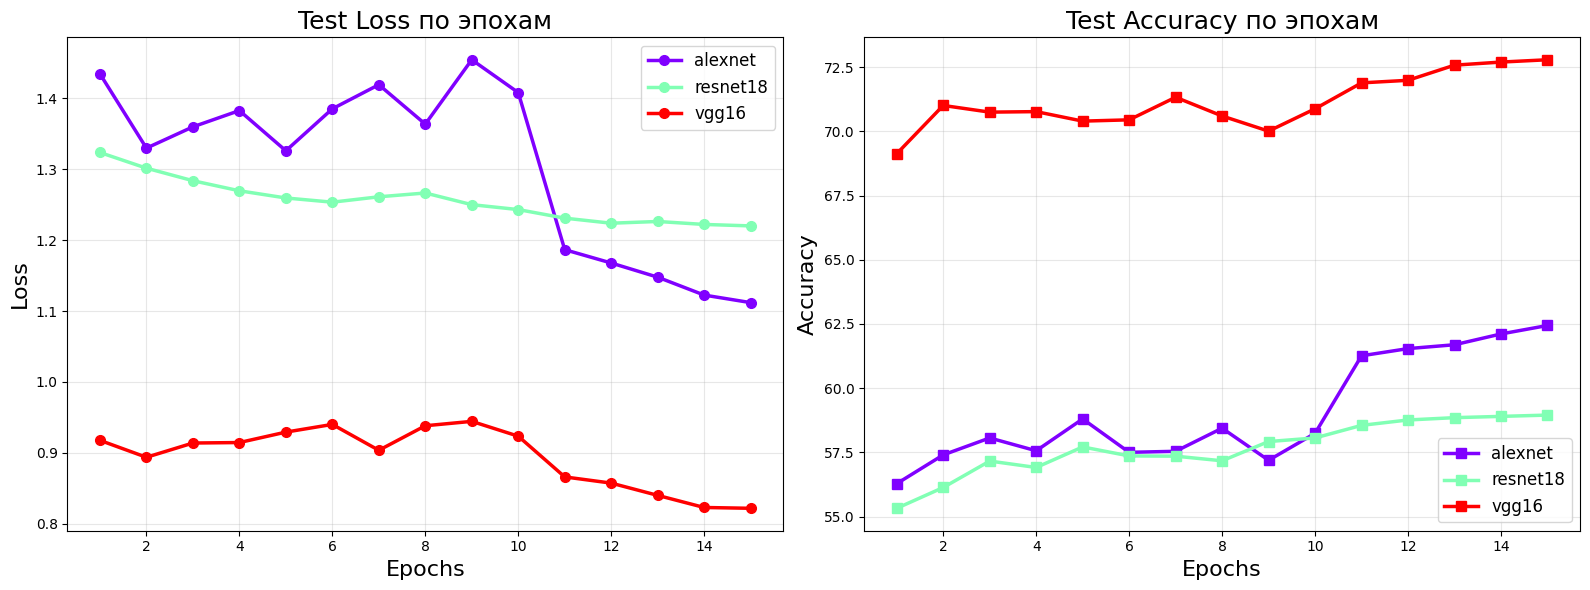

In [ ]:
plot_comparison(results)

### Выводы

Лучше всего показал себя VGG16, что сразу видно из графиков. ResNet же лучше подходит для больших изображений, имеет в 8 раз меньше параметров, поэтому и результат похуже. Дольше всего обучается VGG, но всего лишь на 2 минуты, что делает её лучшей моделью для данной задачи. ResNet сходится медленно, но уверенно. VGG сходится побыстрее, но график потерь всё равно плавно убывает, а вот AlexNet сходится быстро, но график потерь не совсем стабилен и скачет.

## Задание 3: Влияние размера обучающей выборки
- 3.1. dataset CIFAR-10
- 3.2. Создайте подвыборки разного размера (1%, 5%, 10%, 25%, 50%, 100% данных)
- 3.3. Для каждого размера обучите модель с переносом обучения (Таблица сравнения метрик)
- 3.4. Постройте график зависимости точности от размера выборки
- 3.5. Проанализируйте кривую обучения

In [ ]:
from torch.utils.data import DataLoader, Subset

def get_subset_loaders(batch_size: int = 128, subset_percent: float = 1.0) -> Tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(64, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    test_transform = transforms.Compose([
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                           (0.2023, 0.1994, 0.2010))
    ])

    train_dataset_full = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_transform
    )

    if subset_percent < 1.0:
        total_train = len(train_dataset_full)
        subset_size = int(total_train * subset_percent)

        np.random.seed(42)
        indices = np.random.choice(total_train, subset_size, replace=False)
        train_dataset = Subset(train_dataset_full, indices)

        print(f"Используется {subset_size} из {total_train} тренировочных примеров ({subset_percent*100:.0f}%)")
    else:
        train_dataset = train_dataset_full
        print(f"Используется полный датасет: {len(train_dataset_full)} примеров")

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader

In [ ]:
def run_subset_experiment(subset_percent: float = 1.0,
                         base_model: str = "vgg16",
                         epochs: int = 15,
                         batch_size: int = 128,
                         learning_rate: float = 0.001) -> Dict:

    model = TransferLearningModel(num_classes=10, base_model=base_model, freeze_backbone=True)

    train_loader, test_loader = get_subset_loaders(batch_size=batch_size, subset_percent=subset_percent)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        method_name=f"{base_model.upper()} ({subset_percent*100:.0f}% данных)"
    )

    history['subset_percent'] = subset_percent
    history['subset_size'] = int(50000 * subset_percent)

    return history

In [ ]:
results = {}

In [ ]:
subset_percent = 0.01

history = run_subset_experiment(
    subset_percent=subset_percent,
    base_model="vgg16",
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)

results[f"{int(subset_percent*100)}%"] = history

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Используется 500 из 50000 тренировочных примеров (1%)
Using device: cuda
Training with VGG16 (1% данных)

Epoch: 1/15
--------------------------------------------------
Train Loss: 2.2443 | Train Acc: 21.00%
Test Loss: 1.5971 | Test Acc: 45.54%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.5035 | Train Acc: 46.20%
Test Loss: 1.2809 | Test Acc: 55.88%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.2005 | Train Acc: 55.40%
Test Loss: 1.2458 | Test Acc: 56.95%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.1122 | Train Acc: 60.00%
Test Loss: 1.1945 | Test Acc: 59.24%

Epoch: 5/15
--------------------------------------------------
Train Loss: 0.9587 | Train Acc: 66.20%
Test Loss: 1.1554 | Test Acc: 60.87%

Epoch: 6/15
--------------------------------------------------
Train Loss: 0.9329 | Train Acc: 63.80%
Test Loss: 1.1291 | Test Acc: 62.35%

Epoch: 7/15
------------------------------------------

In [ ]:
subset_percent = 0.05

history = run_subset_experiment(
    subset_percent=subset_percent,
    base_model="vgg16",
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)

results[f"{int(subset_percent*100)}%"] = history

Используется 2500 из 50000 тренировочных примеров (5%)
Using device: cuda
Training with VGG16 (5% данных)

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.6175 | Train Acc: 42.68%
Test Loss: 1.1188 | Test Acc: 61.87%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.1811 | Train Acc: 59.20%
Test Loss: 1.0680 | Test Acc: 64.42%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.1234 | Train Acc: 59.72%
Test Loss: 1.0059 | Test Acc: 66.40%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.1036 | Train Acc: 62.12%
Test Loss: 1.0061 | Test Acc: 66.18%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.0468 | Train Acc: 61.72%
Test Loss: 1.0129 | Test Acc: 66.17%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.0133 | Train Acc: 65.56%
Test Loss: 0.9803 | Test Acc: 67.03%

Epoch: 7/15
-----------------------------------------

In [ ]:
subset_sizes = [0.10, 0.25, 0.50, 1.0]

for subset_percent in subset_sizes:
    history = run_subset_experiment(
        subset_percent=subset_percent,
        base_model="vgg16",
        epochs=15,
        batch_size=128,
        learning_rate=0.001
    )
    results[f"{int(subset_percent*100)}%"] = history

Используется 5000 из 50000 тренировочных примеров (10%)
Using device: cuda
Training with VGG16 (10% данных)

Epoch: 1/15
--------------------------------------------------
Train Loss: 1.4698 | Train Acc: 48.46%
Test Loss: 1.0233 | Test Acc: 65.23%

Epoch: 2/15
--------------------------------------------------
Train Loss: 1.1966 | Train Acc: 59.66%
Test Loss: 0.9456 | Test Acc: 67.29%

Epoch: 3/15
--------------------------------------------------
Train Loss: 1.1130 | Train Acc: 60.30%
Test Loss: 0.9937 | Test Acc: 66.91%

Epoch: 4/15
--------------------------------------------------
Train Loss: 1.1187 | Train Acc: 61.06%
Test Loss: 0.9519 | Test Acc: 67.82%

Epoch: 5/15
--------------------------------------------------
Train Loss: 1.0577 | Train Acc: 61.72%
Test Loss: 0.9544 | Test Acc: 67.73%

Epoch: 6/15
--------------------------------------------------
Train Loss: 1.1119 | Train Acc: 62.64%
Test Loss: 1.0184 | Test Acc: 66.89%

Epoch: 7/15
---------------------------------------

In [ ]:
def compare_subset_results(results):
    data = []

    for name, history in results.items():
        data.append({
            'subset': name,
            'loss': f"{history['test_loss'][-1]:.4f}",
            'accuracy': f"{history['test_accuracy'][-1]:.2f}",
            'train_loss': f"{history['train_loss'][-1]:.4f}",
            'num_samples': history['subset_size'],
            'time': f"{history['training_time']:.2f}"
        })

    df = pd.DataFrame(data)
    return df

In [23]:
def plot_train_loss(results):
    for name, data in results.items():
        print(f"{name}: {data['training_time']:.2f} сек")

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))

    for (name, data), color in zip(results.items(), colors):
        epochs = range(1, len(data['train_loss']) + 1)
        ax.plot(epochs, data['train_loss'], label=name, color=color, linewidth=2.5, marker='o', markersize=7)

    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.set_title('Train Loss по эпохам', fontsize=18)
    ax.legend(loc='best', fontsize=12)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# 3.3
df = compare_subset_results(results)
df

,subset,loss,accuracy,train_loss,num_samples,time
0,1%,1.1373,63.12,0.7688,500,86.00
1,5%,0.9603,68.52,0.9220,2500,109.23
2,10%,0.9370,69.16,0.9622,5000,124.93
3,25%,0.8834,70.91,1.0267,12500,187.61
4,50%,0.8480,72.46,1.0467,25000,298.86
5,100%,0.8133,72.91,1.0415,50000,524.67


1%: 86.00 сек
5%: 109.23 сек
10%: 124.93 сек
25%: 187.61 сек
50%: 298.86 сек
100%: 524.67 сек


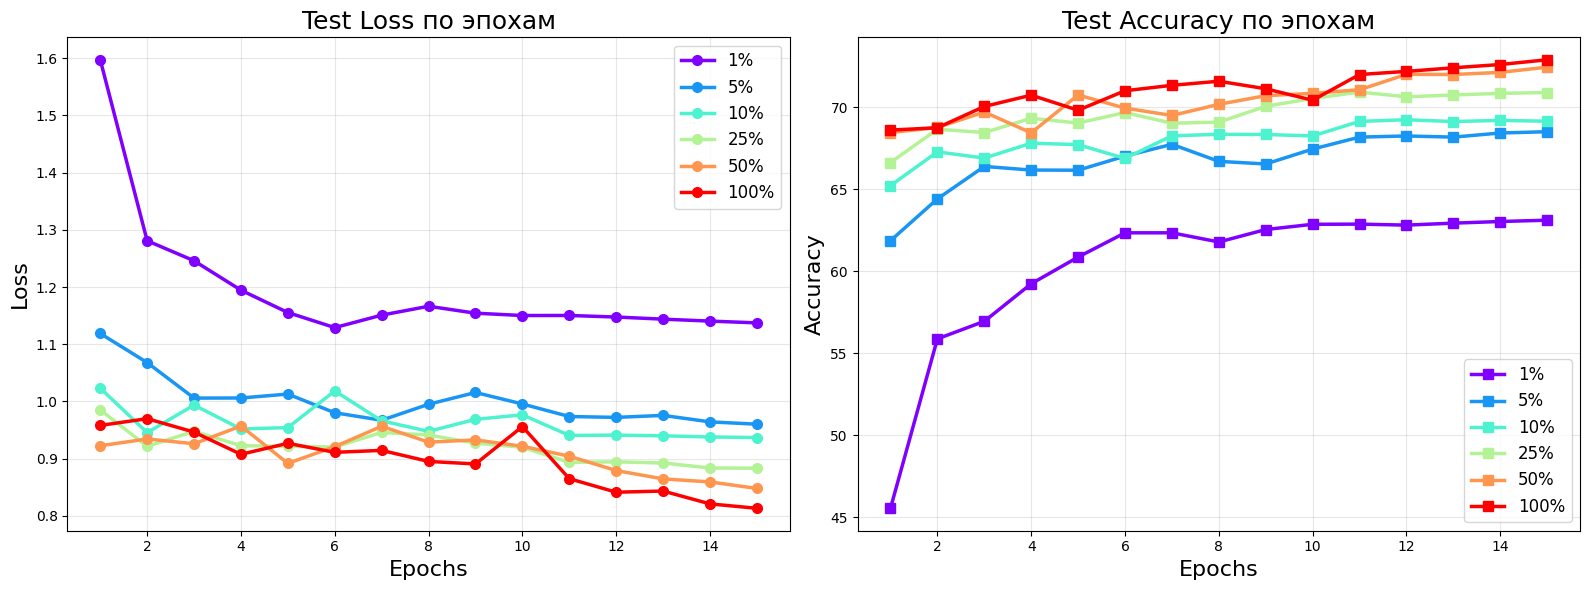

In [ ]:
# 3.4
plot_comparison(results)

1%: 86.00 сек
5%: 109.23 сек
10%: 124.93 сек
25%: 187.61 сек
50%: 298.86 сек
100%: 524.67 сек


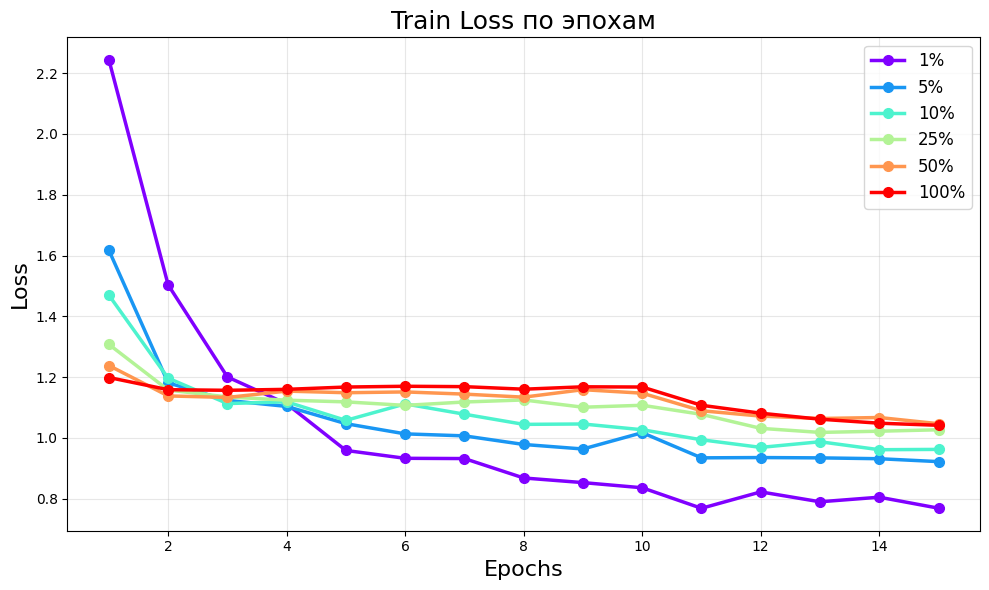

In [ ]:
# 3.5
plot_train_loss(results)

### Выводы

1. Скорость сходимости зависит от размера выборки. Чем меньше выборка, тем быстрее она сходится. На самом деле модель переобучается на маленьком количестве данных.
2. Для выборок большого размера наблюдается медленная, но уверенная сходимость. То есть. чем больше данных, тем медленне сходимость, но зато нет переобучения.
3. Результаты для 50% и для 100% почти совпадают, то есть модели, обученные на таких размерах данных, имеют одинаковую обобщающую способность. Но зато в 2 раза быстрее проходит обучение для 50% выборки.

## Задание 4: Поэтапное размораживание слоев
- 4.1. Реализуйте стратегию постепенного размораживания слоев ResNet-18.
- 4.2. Начните с замороженного backbone, обучайте только классификатор.
- 4.3. Разморозьте и дообучите последний блок слоев.
- 4.4. Наконец, разморозьте всю модель.
- 4.5. Сравните с одноэтапным fine-tuning.

Визуализация процесса обучения для каждого этапа.
Сравнение стабильности обучения и конечной точности.

In [14]:
class TransferLearningModel(nn.Module):
    def __init__(self, base_model, num_classes: int = 10, freeze_backbone: bool = True):
        super(TransferLearningModel, self).__init__()
        self.backbone = base_model

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [16]:
def run_progressive_unfreezing(base_model: str = "resnet18",
                               epochs_per_stage: list = [5, 5, 5],
                               batch_size: int = 128,
                               learning_rates: list = [0.001, 0.0001, 0.00001]) -> Dict:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    backbone_pr = torchvision.models.resnet18(pretrained=True)
    model = TransferLearningModel(base_model=backbone_pr, num_classes=10, freeze_backbone=True)
    model = model.to(device)

    train_loader, test_loader = get_data_loaders_new(batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'test_loss': [],
        'test_accuracy': [],
        'stage_markers': [],
        'training_time': 0
    }

    total_start_time = time.time()

    stages = [
        ("Stage 1: Only Classifier", ['backbone.fc']),
        ("Stage 2: Classifier + Layer4", ['backbone.layer4', 'backbone.fc']),
        ("Stage 3: Full Model", None)
    ]

    current_epoch = 0

    for stage_idx, (stage_name, layers_to_unfreeze) in enumerate(stages):
        if layers_to_unfreeze is None:
            for param in model.parameters():
                param.requires_grad = True
        else:
            for param in model.parameters():
                param.requires_grad = False

            for layer_name in layers_to_unfreeze:
                layer = model
                for attr in layer_name.split('.'):
                    layer = getattr(layer, attr)
                for param in layer.parameters():
                    param.requires_grad = True

        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Trainable parameters: {trainable_params:,} / {total_params:,}\n")

        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rates[stage_idx], weight_decay=1e-4)

        epochs = epochs_per_stage[stage_idx]
        for epoch in range(epochs):
            current_epoch += 1
            print(f'epoch: {current_epoch}, stage {stage_idx+1}')

            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += targets.size(0)
                correct += predicted.eq(targets).sum().item()

            train_acc = 100. * correct / total
            train_loss = running_loss / len(train_loader)

            print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')

            model.eval()
            test_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for inputs, targets in test_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)

                    test_loss += loss.item()
                    _, predicted = outputs.max(1)
                    total += targets.size(0)
                    correct += predicted.eq(targets).sum().item()

            test_acc = 100. * correct / total
            test_loss = test_loss / len(test_loader)

            print(f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%\n')

            history['train_loss'].append(train_loss)
            history['train_accuracy'].append(train_acc)
            history['test_loss'].append(test_loss)
            history['test_accuracy'].append(test_acc)

        history['stage_markers'].append(current_epoch)

    total_time = time.time() - total_start_time
    history['training_time'] = total_time

    print(f'Total training time: {total_time:.2f} sec')

    return history

In [20]:
history_progressive = run_progressive_unfreezing(
        base_model="resnet18",
        epochs_per_stage=[4, 4, 7],
        batch_size=128,
        learning_rates=[0.001, 0.0005, 0.0001]
)

Trainable parameters: 5,130 / 11,181,642

epoch: 1, stage 1
Train Loss: 1.4717 | Train Acc: 49.40%
Test Loss: 1.3435 | Test Acc: 54.57%

epoch: 2, stage 1
Train Loss: 1.2829 | Train Acc: 56.19%
Test Loss: 1.2788 | Test Acc: 56.78%

epoch: 3, stage 1
Train Loss: 1.2547 | Train Acc: 56.69%
Test Loss: 1.2557 | Test Acc: 57.80%

epoch: 4, stage 1
Train Loss: 1.2518 | Train Acc: 57.15%
Test Loss: 1.2725 | Test Acc: 57.03%

Trainable parameters: 8,398,858 / 11,181,642

epoch: 5, stage 2
Train Loss: 0.7689 | Train Acc: 73.91%
Test Loss: 0.5258 | Test Acc: 81.76%

epoch: 6, stage 2
Train Loss: 0.5305 | Train Acc: 81.63%
Test Loss: 0.5043 | Test Acc: 82.35%

epoch: 7, stage 2
Train Loss: 0.4564 | Train Acc: 84.07%
Test Loss: 0.4595 | Test Acc: 84.14%

epoch: 8, stage 2
Train Loss: 0.4153 | Train Acc: 85.41%
Test Loss: 0.4692 | Test Acc: 84.04%

Trainable parameters: 11,181,642 / 11,181,642

epoch: 9, stage 3
Train Loss: 0.2782 | Train Acc: 90.17%
Test Loss: 0.3425 | Test Acc: 88.18%

epoch: 10,

In [17]:
def run_fine_tuning_classic(base_model: str = "resnet18",
                   epochs: int = 10,
                   batch_size: int = 128,
                   learning_rate: float = 0.001) -> Dict:

    model = TransferLearningModel(num_classes=10, base_model=base_model, freeze_backbone=False)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

    train_loader, test_loader = get_data_loaders_new(batch_size=batch_size)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        method_name="Fine-Tuning classic"
    )

    return history

In [18]:
history_classic = run_fine_tuning_classic(
    base_model=torchvision.models.resnet18(pretrained=True),
    epochs=15,
    batch_size=128,
    learning_rate=0.001
)

Trainable parameters: 11,181,642 / 11,181,642
Using device: cuda
Training with Fine-Tuning classic

Epoch: 1/15
--------------------------------------------------
Train Loss: 0.7058 | Train Acc: 76.09%
Test Loss: 0.6238 | Test Acc: 79.38%

Epoch: 2/15
--------------------------------------------------
Train Loss: 0.4710 | Train Acc: 84.09%
Test Loss: 0.4818 | Test Acc: 83.87%

Epoch: 3/15
--------------------------------------------------
Train Loss: 0.4028 | Train Acc: 86.57%
Test Loss: 0.5447 | Test Acc: 82.37%

Epoch: 4/15
--------------------------------------------------
Train Loss: 0.3660 | Train Acc: 87.52%
Test Loss: 0.4979 | Test Acc: 83.92%

Epoch: 5/15
--------------------------------------------------
Train Loss: 0.3328 | Train Acc: 88.65%
Test Loss: 0.4043 | Test Acc: 87.07%

Epoch: 6/15
--------------------------------------------------
Train Loss: 0.3111 | Train Acc: 89.38%
Test Loss: 0.3631 | Test Acc: 87.84%

Epoch: 7/15
------------------------------------------------

In [21]:
results = {
    'Fine-Tuning progressive unfreezing': history_progressive,
    'Fine-Tuning classic': history_classic
}

Fine-Tuning progressive unfreezing: 467.27 сек
Fine-Tuning classic: 472.50 сек


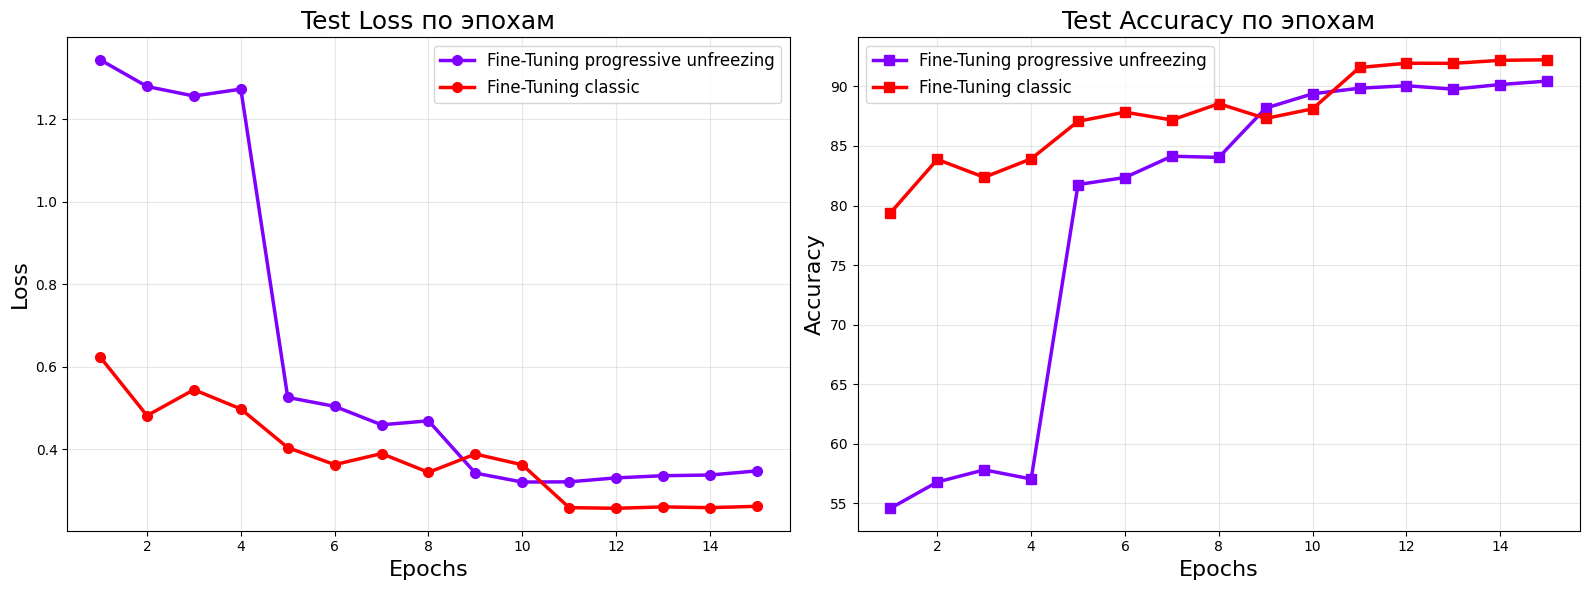

In [22]:
plot_comparison(results)

Fine-Tuning progressive unfreezing: 467.27 сек
Fine-Tuning classic: 472.50 сек


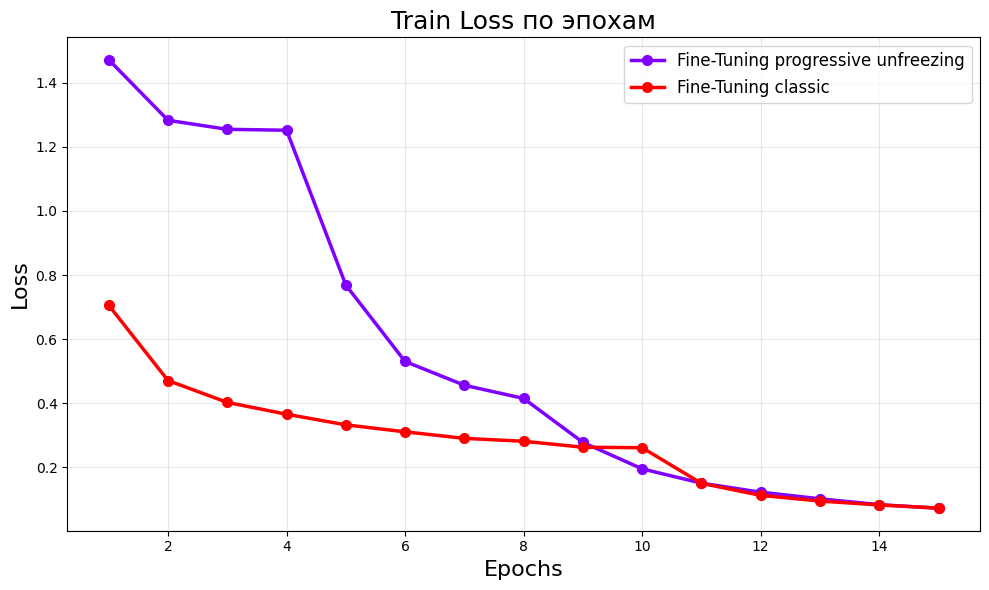

In [24]:
plot_train_loss(results)

### Выводы

1. Каждый новый этап динамического файн-тюнинга делает скачок. На 1-ом этапе медленный рост, но, начиная с 5 эпохи лосс резко уменьшается, а accuracy увеличивается. Это происходит потому что размораживается layer4, и модель лучше подстраивается под задачу классификации CIFAR. То же самое происходит и для 3 этапа - когда размораживаются все слои.
2. В это же время классический fine-tuning медленно, но стабильно обучается, причём имеет более низкий лосс и лучший accuracy.
3. То есть для CIFAR классический файн-тюнинг с разморозкой всех слоёв, даёт лучший результат, чем осторожный файн-тюнинг с постепенной разморозкой слоёв. Это связано с тем, что CIFAR - достаточно большой, поэтому дообучение всей сети не испортит веса, а наоборот, лучше подгонит их под новую задачу. Вот если бы датасет был маленький, то осторожный файн-тюнинг был бы лучше, а классический бы переобучил модель.

## Задание 5: Адаптация под другую задачу

- 5.1. Используйте Food101 (https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.Food101.html#torchvision.datasets.Food101)
- 5.2. Настройте предобученную модель для классификации Food101
- 5.3. Экспериментируйте с различными функциями активации на выходе
- 5.4. Сравните разные стратегии инициализации последнего слоя

In [30]:
from torch.utils.data import DataLoader, Subset

In [25]:
def get_food101_loaders(batch_size: int = 64, subset_size: int = None):
    train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    train_dataset_full = torchvision.datasets.Food101(
        root='./data', split='train', download=True, transform=train_transform
    )

    test_dataset = torchvision.datasets.Food101(
        root='./data', split='test', download=True, transform=test_transform
    )

    if subset_size is not None:
        print(f"Используется subset: {subset_size} примеров из {len(train_dataset_full)}")
        indices = np.random.choice(len(train_dataset_full), subset_size, replace=False)
        train_dataset = Subset(train_dataset_full, indices)
    else:
        train_dataset = train_dataset_full

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
    )

    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    print(f"Train samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    return train_loader, test_loader

In [26]:
class Food101Model(nn.Module):
    def __init__(self, num_classes: int = 101,
                 activation: str = "none",
                 init_method: str = "default"):

        super(Food101Model, self).__init__()

        self.backbone = torchvision.models.resnet18(pretrained=True)

        for param in self.backbone.parameters():
            param.requires_grad = False

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, num_classes)

        self._initialize_fc(init_method)

        if activation == "relu":
            self.activation = nn.ReLU()
        elif activation == "sigmoid":
            self.activation = nn.Sigmoid()
        elif activation == "tanh":
            self.activation = nn.Tanh()
        else:
            self.activation = None

        self.activation_name = activation
        self.init_method = init_method

    def _initialize_fc(self, method: str):
        fc_layer = self.backbone.fc

        if method == "xavier":
            nn.init.xavier_uniform_(fc_layer.weight)
            nn.init.zeros_(fc_layer.bias)
        elif method == "he":
            nn.init.kaiming_uniform_(fc_layer.weight, mode='fan_in', nonlinearity='relu')
            nn.init.zeros_(fc_layer.bias)
        elif method == "zeros":
            nn.init.zeros_(fc_layer.weight)
            nn.init.zeros_(fc_layer.bias)

    def forward(self, x):
        x = self.backbone(x)
        if self.activation is not None:
            x = self.activation(x)
        return x

In [27]:
def experiment_activations(train_loader, test_loader, epochs: int = 10):
    activations = ["none", "relu", "sigmoid", "tanh"]
    results = {}

    for activation in activations:
        print(f"activ = {activation}")
        model = Food101Model(num_classes=101, activation=activation, init_method="default")

        history = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=epochs,
            learning_rate=0.001,
            method_name=f"Activation: {activation}"
        )

        history['activation'] = activation
        history['init_method'] = 'default'
        results[f"activation_{activation}"] = history

    return results

In [28]:
def experiment_initializations(train_loader, test_loader, epochs: int = 5):
    init_methods = ["default", "xavier", "he", "zeros"]
    results = {}

    for init_method in init_methods:
        print(f"init = {init_method}")
        model = Food101Model(num_classes=101, activation="none", init_method=init_method)

        history = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            epochs=epochs,
            learning_rate=0.001,
            method_name=f"Initialization: {init_method}"
        )

        history['activation'] = 'none'
        history['init_method'] = init_method
        results[f"init_{init_method}"] = history

    return results

In [34]:
dataset_size = 75750

train_loader, test_loader = get_food101_loaders(
    batch_size=128,
    subset_size=dataset_size // 4
)

Используется subset: 18937 примеров из 75750
Train samples: 18937
Test samples: 25250


In [35]:
results_activations = experiment_activations(train_loader, test_loader, epochs=5)

activ = none
Using device: cuda
Training with Activation: none

Epoch: 1/5
--------------------------------------------------
Train Loss: 3.7207 | Train Acc: 21.12%
Test Loss: 2.8406 | Test Acc: 39.21%

Epoch: 2/5
--------------------------------------------------
Train Loss: 2.6345 | Train Acc: 41.93%
Test Loss: 2.3283 | Test Acc: 45.83%

Epoch: 3/5
--------------------------------------------------
Train Loss: 2.2732 | Train Acc: 47.49%
Test Loss: 2.0982 | Test Acc: 49.62%

Epoch: 4/5
--------------------------------------------------
Train Loss: 2.0849 | Train Acc: 50.73%
Test Loss: 1.9941 | Test Acc: 51.09%

Epoch: 5/5
--------------------------------------------------
Train Loss: 1.9706 | Train Acc: 52.57%
Test Loss: 1.9073 | Test Acc: 52.70%

Training completed in 1050.51 seconds
activ = relu
Using device: cuda
Training with Activation: relu

Epoch: 1/5
--------------------------------------------------
Train Loss: 4.4371 | Train Acc: 9.06%
Test Loss: 4.2810 | Test Acc: 13.64%

E

activation_none: 1050.51 сек
activation_relu: 1027.46 сек
activation_sigmoid: 1011.17 сек
activation_tanh: 1009.72 сек


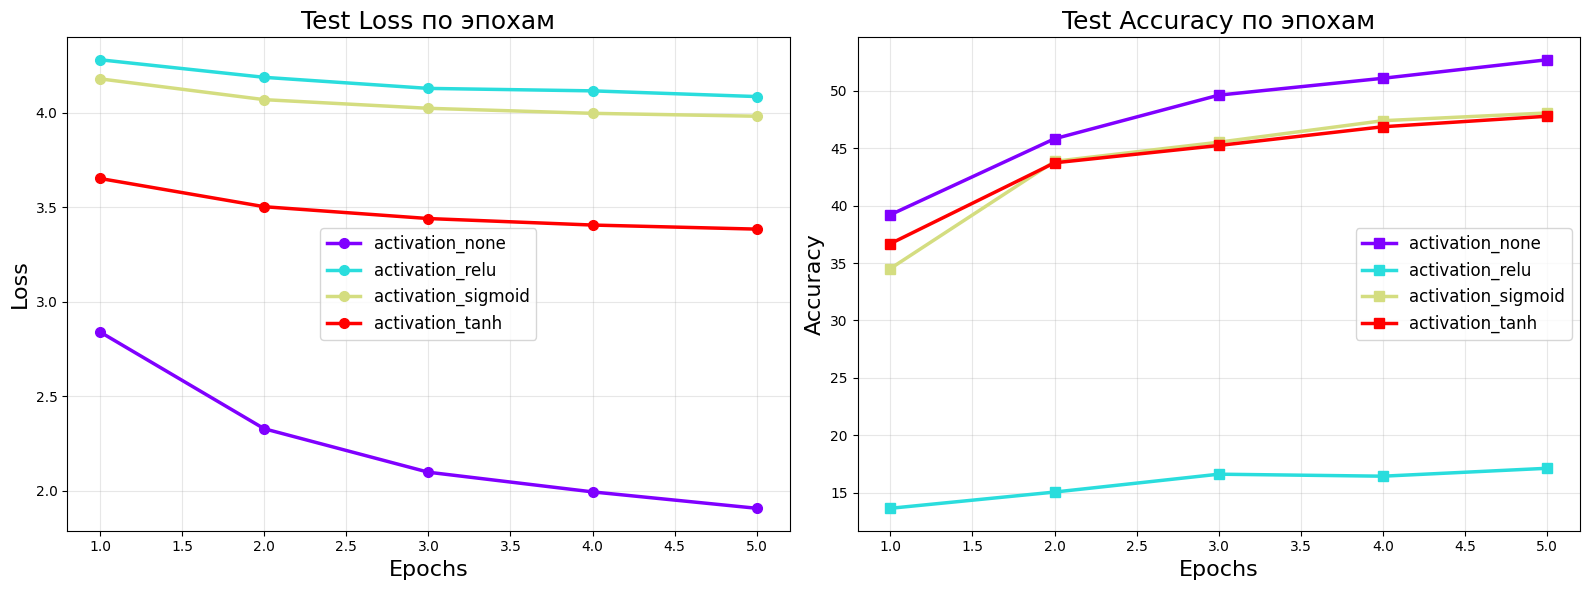

In [36]:
plot_comparison(results_activations)

In [37]:
results_initializations = experiment_initializations(train_loader, test_loader, epochs=5)

init = default
Using device: cuda
Training with Initialization: default

Epoch: 1/5
--------------------------------------------------
Train Loss: 3.7309 | Train Acc: 20.58%
Test Loss: 2.8755 | Test Acc: 38.02%

Epoch: 2/5
--------------------------------------------------
Train Loss: 2.6396 | Train Acc: 41.46%
Test Loss: 2.3349 | Test Acc: 46.09%

Epoch: 3/5
--------------------------------------------------
Train Loss: 2.2803 | Train Acc: 47.29%
Test Loss: 2.1186 | Test Acc: 48.74%

Epoch: 4/5
--------------------------------------------------
Train Loss: 2.0940 | Train Acc: 50.15%
Test Loss: 1.9856 | Test Acc: 51.48%

Epoch: 5/5
--------------------------------------------------
Train Loss: 1.9729 | Train Acc: 52.29%
Test Loss: 1.9243 | Test Acc: 51.98%

Training completed in 1007.84 seconds
init = xavier
Using device: cuda
Training with Initialization: xavier

Epoch: 1/5
--------------------------------------------------
Train Loss: 4.0123 | Train Acc: 13.37%
Test Loss: 3.0585 | Te

init_default: 1007.84 сек
init_xavier: 1004.16 сек
init_he: 1006.47 сек
init_zeros: 1017.28 сек


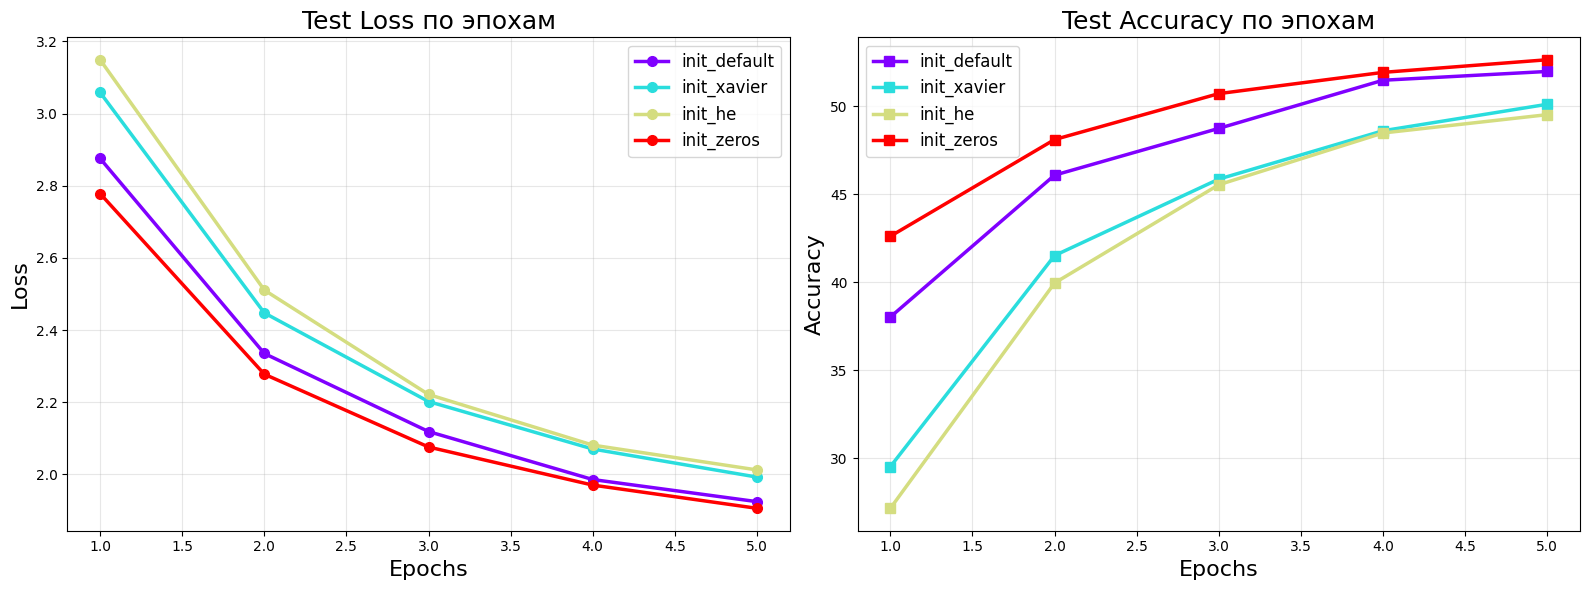

In [38]:
plot_comparison(results_initializations)

activation_none: 1050.51 сек
activation_relu: 1027.46 сек
activation_sigmoid: 1011.17 сек
activation_tanh: 1009.72 сек


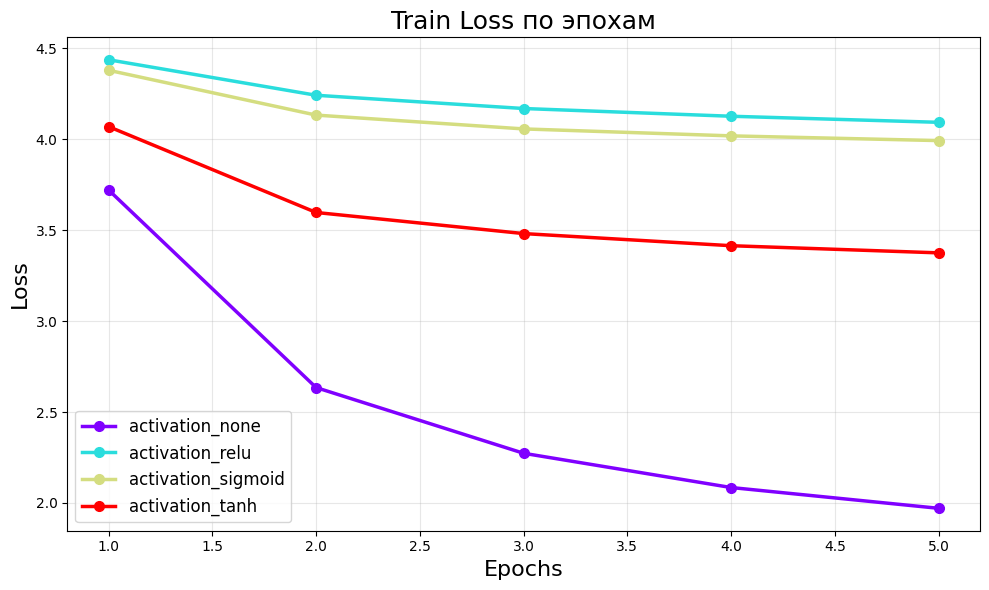

In [39]:
plot_train_loss(results_activations)

init_default: 1007.84 сек
init_xavier: 1004.16 сек
init_he: 1006.47 сек
init_zeros: 1017.28 сек


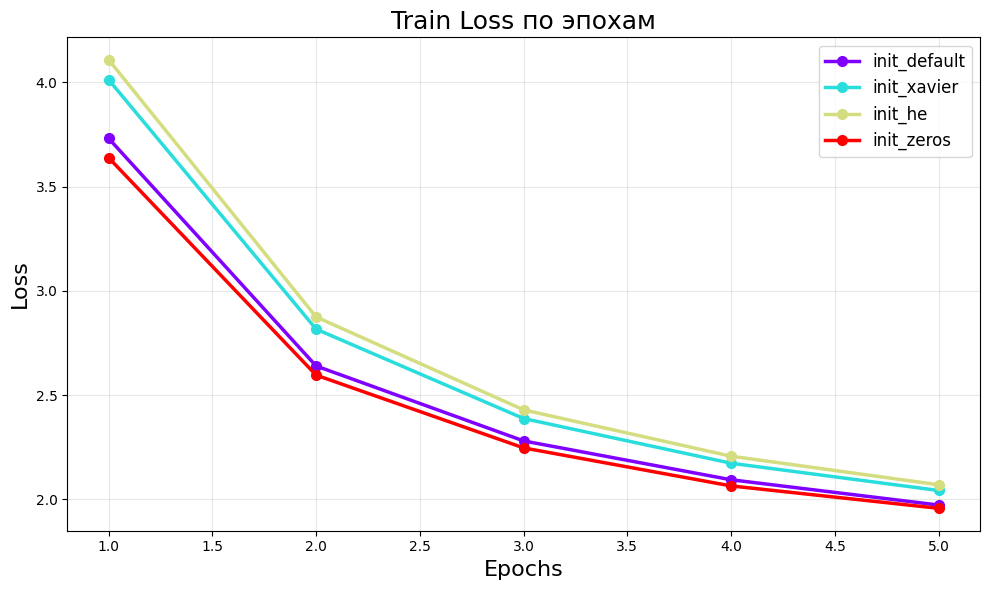

In [40]:
plot_train_loss(results_initializations)